In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
np.random.seed(4)
#Class A cluster
A_x1=np.random.normal(loc=3,scale=0.3,size=10)
A_x2=np.random.normal(loc=3,scale=0.3,size=10)
#Class B cluster
B_x1=np.random.normal(loc=4,scale=0.3,size=10)
B_x2=np.random.normal(loc=4,scale=0.3,size=10)



In [4]:
df = pd.DataFrame({
    "Feature_1": np.concatenate([A_x1, B_x1]),
    "Feature_2": np.concatenate([A_x2, B_x2]),
    "Target": ["Class_A"]*10 + ["Class_B"]*10
})


In [5]:
df.head()

,Feature_1,Feature_2,Target
0,3.015169,3.185601,Class_A
1,3.149985,2.973604,Class_A
2,2.701227,3.127522,Class_A
3,3.208080,3.099676,Class_A
4,2.874510,2.652955,Class_A


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

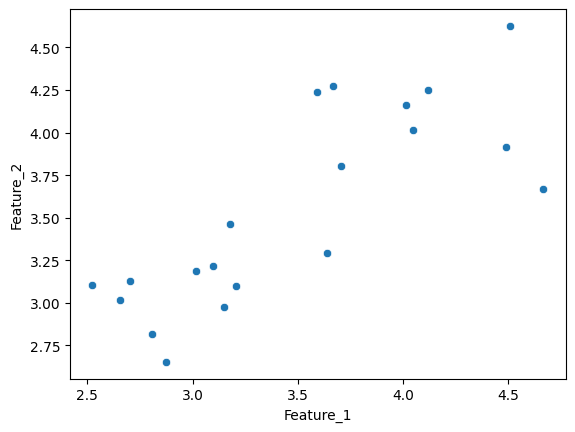

In [6]:
import seaborn as sns
sns.scatterplot(data=df,x='Feature_1',y='Feature_2')

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

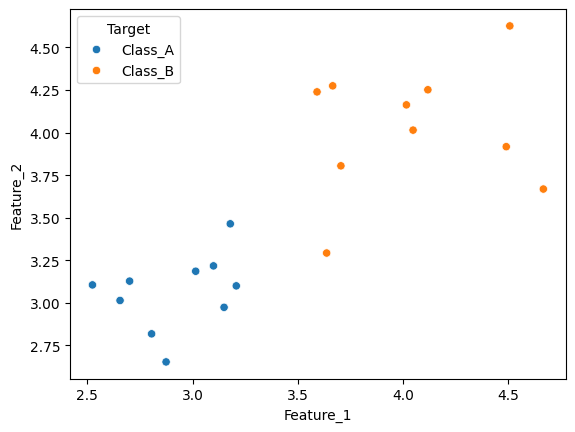

In [7]:
sns.scatterplot(data=df,x='Feature_1',y='Feature_2',hue='Target')


LOOK WE HAVE A PATTERN NOW.WE CAN DIVIDE INTO TWO PART

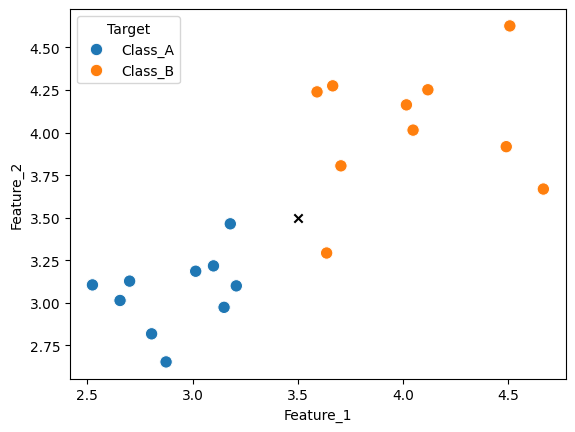

In [8]:
sns.scatterplot(data=df,x='Feature_1',y='Feature_2',hue='Target',s=80)
plt.scatter(x=[3.5],y=[3.5],marker="x",c="black")

we need to figure out whether the cross point(*) will go class A or class B

In [9]:
data_point = np.array([3.5, 3.5])

df['Distance'] = np.sqrt(
    (df['Feature_1'] - data_point[0])**2 +
    (df['Feature_2'] - data_point[1])**2
)


In [10]:
df

,Feature_1,Feature_2,Target,Distance
0,3.015169,3.185601,Class_A,0.577848
1,3.149985,2.973604,Class_A,0.632142
2,2.701227,3.127522,Class_A,0.881350
3,3.208080,3.099676,Class_A,0.495456
4,2.874510,2.652955,Class_A,1.052959
5,2.524627,3.105299,Class_A,1.052208
6,2.805688,2.817934,Class_A,0.973285
7,3.179573,3.464094,Class_A,0.322433
8,3.099675,3.217002,Class_A,0.490253
9,2.655757,3.013841,Class_A,0.974216


In [11]:
df.sort_values(by='Distance')
#if we take k=3 in target column 2 Class_B and 1 Class_A so cross point go to Class_B
#if we take k=5 in target column 3 Class_A and 2 Class_B so cross point go to Class_A
#its problem whats the best value for K?we have to solve it

,Feature_1,Feature_2,Target,Distance
13,3.637316,3.292578,Class_B,0.248756
7,3.179573,3.464094,Class_A,0.322433
10,3.705103,3.804632,Class_B,0.367244
8,3.099675,3.217002,Class_A,0.490253
3,3.208080,3.099676,Class_A,0.495456
0,3.015169,3.185601,Class_A,0.577848
1,3.149985,2.973604,Class_A,0.632142
19,3.591710,4.238954,Class_B,0.744623
12,4.047968,4.014402,Class_B,0.751584
17,3.666156,4.274452,Class_B,0.792076


In [12]:
data=pd.read_csv('Classified Data.txt',index_col=0)
data.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   WTT           1000 non-null   float64
 1   PTI           1000 non-null   float64
 2   EQW           1000 non-null   float64
 3   SBI           1000 non-null   float64
 4   LQE           1000 non-null   float64
 5   QWG           1000 non-null   float64
 6   FDJ           1000 non-null   float64
 7   PJF           1000 non-null   float64
 8   HQE           1000 non-null   float64
 9   NXJ           1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 93.8 KB


in KNN just we have to check any missing value are in our dataset.

In [14]:
feature=data.drop(columns='TARGET CLASS')
target=data['TARGET CLASS']

In [15]:
#Scaling(standraization)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scalled_feature=scaler.fit_transform(feature)


Now all value are in almost closed range

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(scalled_feature,target,train_size=.8,random_state=42)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=7)
KNN.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [18]:
prediction=KNN.predict(x_test)
prediction

array([0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 1])

In [19]:
from sklearn.metrics import classification_report
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.93      0.96      0.94        98
           1       0.96      0.93      0.95       102

    accuracy                           0.94       200
   macro avg       0.95      0.95      0.94       200
weighted avg       0.95      0.94      0.95       200



If we change ta K value precision,recall... will be change again and again.
So lets find best K for best accuracy

In [20]:
from sklearn.metrics import accuracy_score
k_values=range(1,50,2)#let k best value in betwwn 1 to 50.(1,3,5,7,9,........)
test_score=[]
for i in k_values:
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(x_train,y_train)
    pred=model.predict(x_test)
    accuracy=accuracy_score(y_test,pred)
    test_score.append(accuracy)
    max_accurcy_indx=np.argmax(test_score)#return max value index position
    max_accurcy_value=k_values[max_accurcy_indx]
    

In [22]:
print("Best score:",max(test_score))
print("Best K:",max_accurcy_indx)

Best score: 0.96
Best K: 6
